# Noise Module Test Visualization

This notebook complements the pytest suite by plotting the expected behaviour of the refactored `NoiseGenerator` and the three new modules.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'wk7').exists():
    ROOT = ROOT.parent
if not (ROOT / 'wk7').exists():
    raise RuntimeError('Could not locate repository root containing wk7/')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from wk7.noise_module import (
    ArtifactInjector,
    MultiChannelNoiseGenerator,
    NoiseGenerator,
    TemporalNoiseWrapper,
)


In [2]:
BASE_CONFIG = {
    'noise_type': 'pink',
    'noise_power': 1.0,
    'sampling_frequency': 2000.0,
}
TEMPORAL_CONFIG = {
    'mode': 'piecewise',
    'n_segments': 4,
    'crossfade_len': 128,
    'vary_noise_power': True,
    'noise_power_scale_range': [0.7, 1.3],
    'add_drift': True,
    'drift_sigma': 0.08,
    'drift_n_knots': 6,
}
ARTIFACT_CONFIG = {
    'sampling_frequency': 2000.0,
    'enable_lines': True,
    'lines': [
        {'freq': 50.0, 'amp': 0.03, 'phase': 'random', 'harmonics': [1, 2]},
        {'freq': 120.0, 'amp': [0.01, 0.02], 'phase': 'random', 'harmonics': [1]},
    ],
    'enable_glitches': True,
    'glitch_rate': 2.0,
    'glitch_amp_range': [0.1, 0.25],
    'glitch_templates': ['impulse', 'exp_decay', 'damped_sine', 'ringing'],
    'glitch_duration_samples': [32, 160],
    'enable_sparse_impulses': True,
    'impulse_probability': 2e-3,
    'impulse_sigma': 0.2,
}
MULTICHANNEL_CONFIG = {
    'mode': 'shared_private',
    'n_channels': 8,
    'corr_strength': 0.35,
    'channel_gain_jitter': 0.05,
    'normalize_channel_variance': True,
}
N = 4096


## Run pytest

This cell runs the automated checks in `wk7/noise_module/tests`.

In [3]:
result = subprocess.run(
    [sys.executable, '-m', 'pytest', 'wk7/noise_module/tests', '-q'],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('pytest failed')


........                                                                 [100%]
8 passed in 0.34s



## Base NoiseGenerator

Compare one sample trace and an averaged PSD estimate against the target PSD.

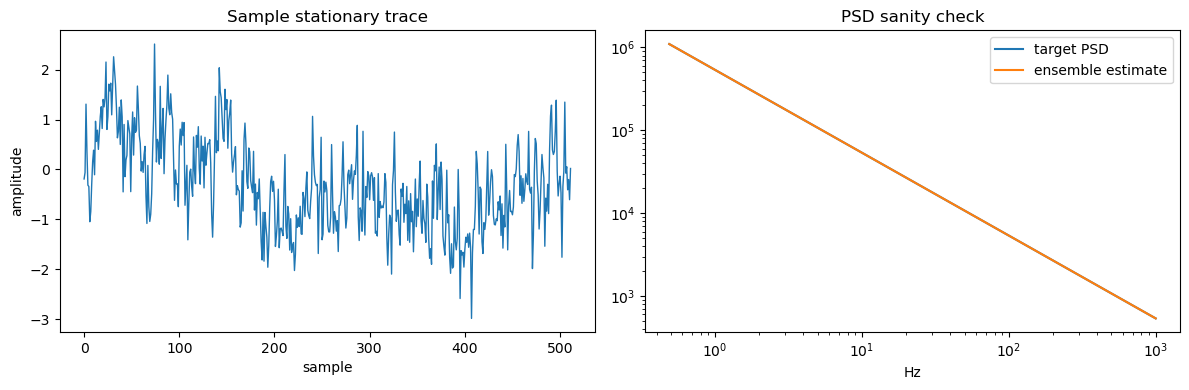

In [4]:
base = NoiseGenerator(BASE_CONFIG, seed=123)
trace, meta = base.generate_noise(N, return_metadata=True)
freqs, target_psd = base.build_psd(N)
ensemble = np.vstack([NoiseGenerator(BASE_CONFIG, seed=seed).generate_noise(N) for seed in range(10)])
estimated_psd = np.mean(np.abs(np.fft.rfft(ensemble, axis=1)) ** 2, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trace[:512], lw=1)
axes[0].set_title('Sample stationary trace')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

axes[1].loglog(freqs[1:], target_psd[1:], label='target PSD')
axes[1].loglog(freqs[1:], estimated_psd[1:] / estimated_psd[1] * target_psd[1], label='ensemble estimate')
axes[1].set_title('PSD sanity check')
axes[1].set_xlabel('Hz')
axes[1].legend()
plt.tight_layout()


## TemporalNoiseWrapper

Show piecewise power changes and additive drift.

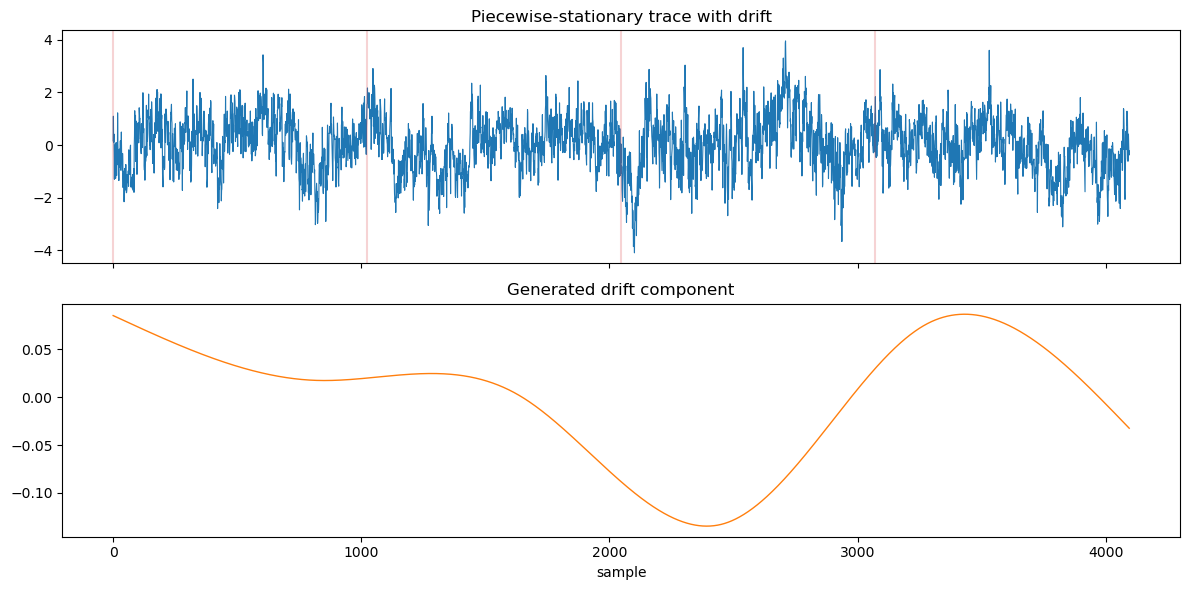

In [5]:
temporal = TemporalNoiseWrapper(TEMPORAL_CONFIG, seed=456)
temporal_trace, temporal_meta = temporal.apply(trace, base_generator=base, return_metadata=True)
drift = temporal.generate_drift(N)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(temporal_trace, lw=0.8)
axes[0].set_title('Piecewise-stationary trace with drift')
for segment in temporal_meta['piecewise']['segments']:
    axes[0].axvline(segment['start'], color='tab:red', alpha=0.2)
axes[1].plot(drift, color='tab:orange', lw=1)
axes[1].set_title('Generated drift component')
axes[1].set_xlabel('sample')
plt.tight_layout()


## ArtifactInjector

Inject lines and glitches, then inspect the spectrum and a trace zoom.

{'lines': {'count': 3,
  'lines': [{'freq': 50.0, 'amp': 0.03},
   {'freq': 100.0, 'amp': 0.03},
   {'freq': 120.0, 'amp': 0.016318460965633646}]},
 'glitches': {'count': 0, 'glitches': []},
 'sparse_impulses': {'count': 2, 'sigma': 0.2},
 'output_std': 1.0293535026915608}

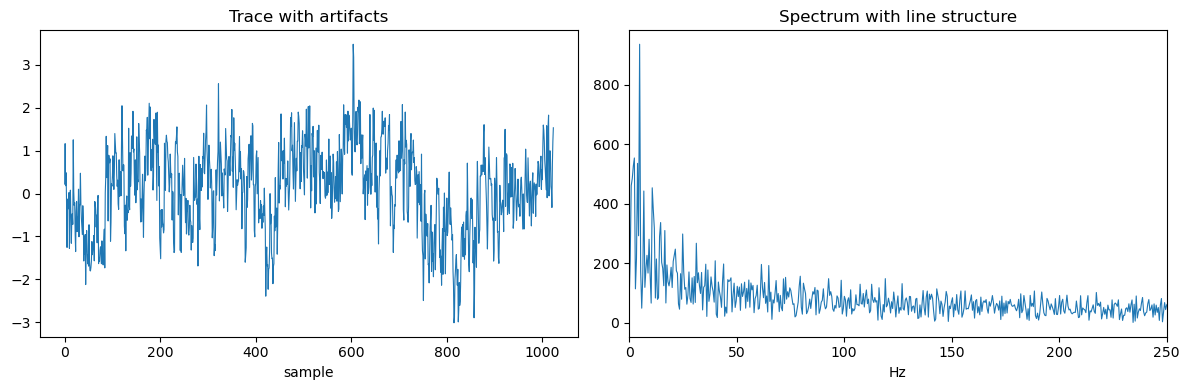

In [6]:
artifact = ArtifactInjector(ARTIFACT_CONFIG, seed=789)
artifact_trace, artifact_meta = artifact.apply(temporal_trace, return_metadata=True)
artifact_freqs = np.fft.rfftfreq(N, d=1.0 / BASE_CONFIG['sampling_frequency'])
artifact_spectrum = np.abs(np.fft.rfft(artifact_trace))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(artifact_trace[:1024], lw=0.8)
axes[0].set_title('Trace with artifacts')
axes[0].set_xlabel('sample')
axes[1].plot(artifact_freqs, artifact_spectrum, lw=0.8)
axes[1].set_xlim(0, 250)
axes[1].set_title('Spectrum with line structure')
axes[1].set_xlabel('Hz')
plt.tight_layout()

artifact_meta


## MultiChannelNoiseGenerator

Compare correlation heatmaps for independent and shared/private modes.

/tmp/ipykernel_284431/2955649248.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


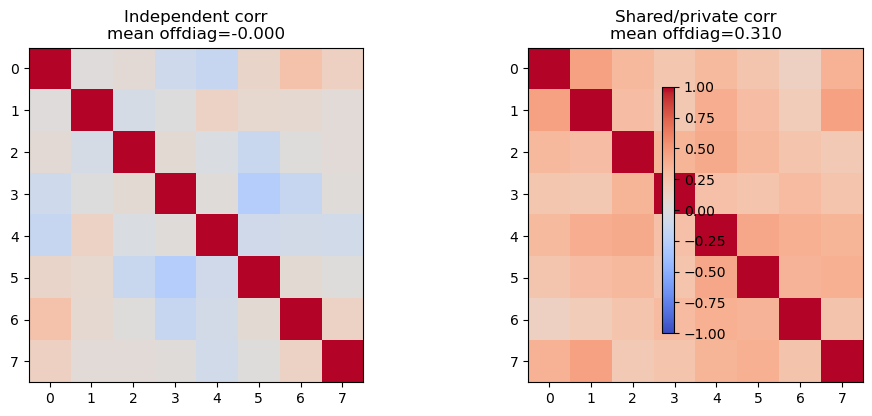

In [7]:
mc = MultiChannelNoiseGenerator(BASE_CONFIG, config=MULTICHANNEL_CONFIG, seed=321)
independent, independent_meta = mc.generate_independent(8, N, return_metadata=True)
shared, shared_meta = mc.generate_shared_private(8, N, corr_strength=0.35, return_metadata=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(np.corrcoef(independent), vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set_title(f"Independent corr\nmean offdiag={independent_meta['mean_offdiag_corr']:.3f}")
im1 = axes[1].imshow(np.corrcoef(shared), vmin=-1, vmax=1, cmap='coolwarm')
axes[1].set_title(f"Shared/private corr\nmean offdiag={shared_meta['mean_offdiag_corr']:.3f}")
fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
